# 04 - Product Profitability

**Objective:** Identify which products drive revenue vs. which drive profit
(they are not always the same products), and flag high-sales/low-margin and
low-sales/high-margin products for management attention.

**Business context:** Revenue-based product rankings can hide products that
are simultaneously "top sellers" and money-losers -- this notebook makes
that gap explicit.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from data_loading import load_orders
from data_cleaning import clean_orders
from feature_engineering import engineer_all

raw = load_orders()
cleaned, _ = clean_orders(raw)
tables = engineer_all(cleaned)
lines = tables['lines']
products = tables['product_level']
print(f"Distinct product/category/sub-category combinations: {len(products):,}")


Distinct product/category/sub-category combinations: 1,894


## Top products by revenue

**Business question: Which products contribute the most revenue?**

In [2]:
top_revenue = products.nlargest(10, 'total_sales')[['product_name','category','sub_category','total_sales','total_profit','profit_margin']]
top_revenue

,product_name,category,sub_category,total_sales,total_profit,profit_margin
1640,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,4.090909e-01
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7.753039e+03,2.824074e-01
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1.811078e+03,-8.000000e-02
82,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,1.136868e-13,5.198164e-18
701,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,1.126697e-01
667,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.500,7.609800e+02,4.000000e-02
1630,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6.983884e+03,3.707006e-01
1657,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4.094977e+03,2.228571e-01
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1.878166e+03,-1.045455e-01
1443,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.312,-2.620048e+02,-1.538462e-02


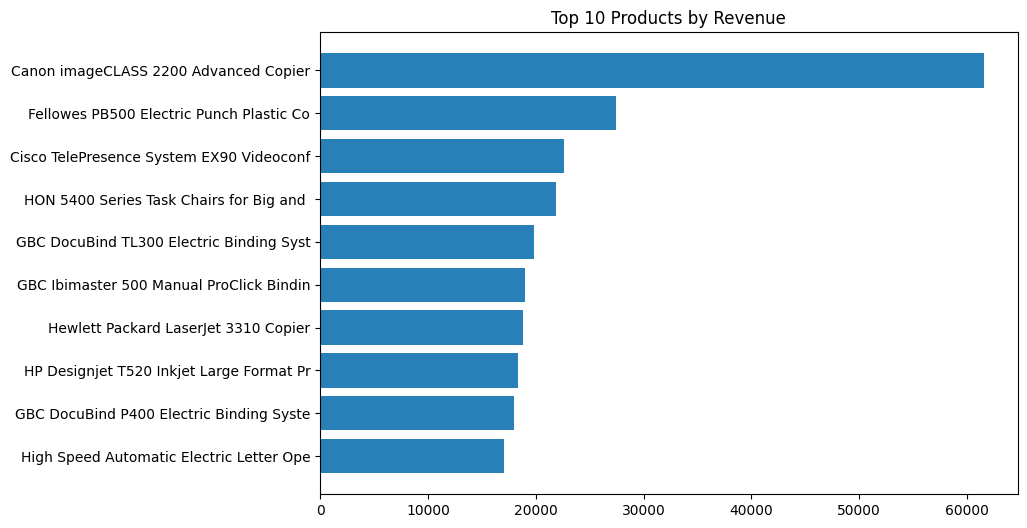

In [3]:
fig, ax = plt.subplots(figsize=(9,6))
top10 = products.nlargest(10,'total_sales')
ax.barh(top10['product_name'].str.slice(0,40), top10['total_sales'], color='#2980b9')
ax.invert_yaxis()
ax.set_title('Top 10 Products by Revenue')
plt.show()


**Interpretation:** the #1 product by revenue (Canon imageCLASS 2200
Advanced Copier, $61,600) is healthily profitable at 40.9% margin. But the
#3 product by revenue (Cisco TelePresence System EX90, $22,638) has a
**-8.0% margin** -- it is simultaneously a top-3 revenue product and a
loss-maker.

## Products with the weakest profit

**Business question: Which products generate weak or negative profit?**

In [4]:
worst_profit = products.nsmallest(10, 'total_profit')[['product_name','category','sub_category','total_sales','total_profit','profit_margin']]
worst_profit

,product_name,category,sub_category,total_sales,total_profit,profit_margin
1645,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.963,-8879.9704,-0.800000
1650,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.901,-4589.9730,-0.272727
1696,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,-3839.9904,-0.480000
326,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.640,-2876.1156,-0.290000
344,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.725,-1934.3976,-0.202667
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1878.1662,-0.104545
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1811.0784,-0.080000
1465,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.200,-1299.1836,-0.078000
346,Balt Solid Wood Round Tables,Furniture,Tables,6518.754,-1201.0581,-0.184247
375,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.250,-1148.4375,-0.673077


**Interpretation:** 6 of the 10 worst-profit products are in Technology's
"Machines" sub-category or Furniture's "Tables" sub-category. The single
worst product (Cubify CubeX 3D Printer Double Head Print) loses money at an
80% rate -- every dollar of revenue costs the business 80 cents.

## High-sales, low-margin products (needs management attention)

**Business question: Which products/categories have high sales but weak
margins?**

Defined here as: revenue in the top quartile of all products, AND margin
below the company-wide average (12.56%).

In [5]:
revenue_p75 = products['total_sales'].quantile(0.75)
overall_margin = lines['profit'].sum() / lines['sales'].sum()
flagged = products[(products['total_sales'] >= revenue_p75) & (products['profit_margin'] < overall_margin)]
flagged_sorted = flagged.sort_values('total_sales', ascending=False)
print(f"{len(flagged_sorted)} products are simultaneously high-revenue and below-average margin.")
flagged_sorted.head(10)[['product_name','category','sub_category','total_sales','profit_margin']]


246 products are simultaneously high-revenue and below-average margin.


,product_name,category,sub_category,total_sales,profit_margin
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.4800,-8.000000e-02
82,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.5760,5.198164e-18
701,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.4790,1.126697e-01
667,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.5000,4.000000e-02
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.0680,-1.045455e-01
1443,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.3120,-1.538462e-02
1650,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.9010,-2.727273e-01
1465,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.2000,-7.800000e-02
49,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,15610.9656,-4.288939e-02
363,Bretford Rectangular Conference Table Tops,Furniture,Tables,13565.5715,-2.649016e-02


## Low-sales, high-margin products (efficient, under-promoted?)

**Business question: Which products/categories have lower sales but
stronger margins?**

Defined here as: revenue in the bottom quartile of all products, AND margin
above the company-wide average.

In [6]:
revenue_p25 = products['total_sales'].quantile(0.25)
efficient = products[(products['total_sales'] <= revenue_p25) & (products['profit_margin'] > overall_margin)]
print(f"{len(efficient)} products are low-revenue but above-average margin.")
efficient.sort_values('profit_margin', ascending=False).head(10)[['product_name','category','sub_category','total_sales','profit_margin']]


382 products are low-revenue but above-average margin.


,product_name,category,sub_category,total_sales,profit_margin
1299,Southworth Structures Collection,Office Supplies,Paper,72.80,0.50
1001,Avery 5,Office Supplies,Labels,5.76,0.49
1012,Color-Coded Legal Exhibit Labels,Office Supplies,Labels,14.73,0.49
984,Avery 478,Office Supplies,Labels,88.38,0.49
1118,Rediform S.O.S. Phone Message Books,Office Supplies,Paper,19.92,0.49
1255,Xerox 1987,Office Supplies,Paper,92.48,0.49
1251,Xerox 1969,Office Supplies,Paper,11.56,0.49
1166,Xerox 1984,Office Supplies,Paper,12.96,0.49
1107,Xerox 1983,Office Supplies,Paper,29.90,0.49
1145,Xerox 193,Office Supplies,Paper,77.74,0.49


**Interpretation:** this second group represents products that are
profitable per dollar sold but have low volume -- candidates for increased
promotion or shelf placement, though this notebook does not have data on
*why* their volume is low (e.g. price point, awareness, seasonality) and
does not claim to.

## Sub-category margin overview

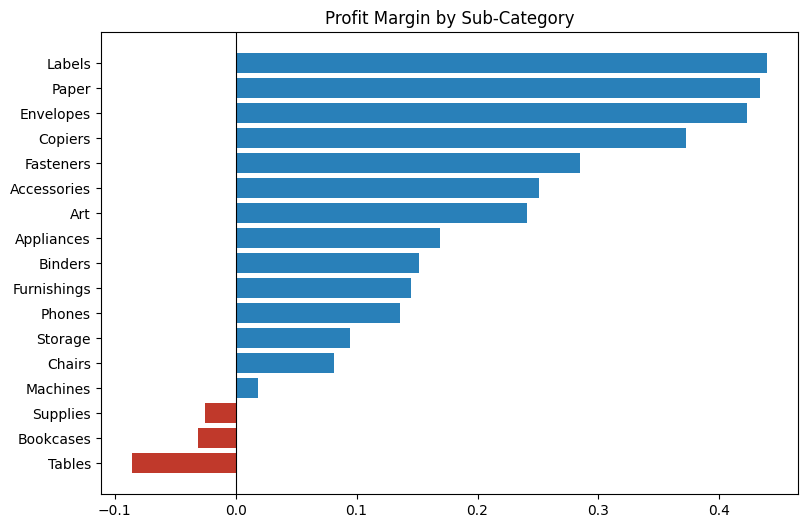

In [7]:
subcategory_summary = (lines.groupby('sub_category')
    .agg(revenue=('sales','sum'), profit=('profit','sum'))
    .reset_index())
subcategory_summary['margin'] = subcategory_summary['profit']/subcategory_summary['revenue']
df_sorted = subcategory_summary.sort_values('margin')

fig, ax = plt.subplots(figsize=(9,6))
colors = ['#c0392b' if m < 0 else '#2980b9' for m in df_sorted['margin']]
ax.barh(df_sorted['sub_category'], df_sorted['margin'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit Margin by Sub-Category')
plt.show()
